# 人体分割

来自 [AI 初学者课程](https://github.com/microsoft/ai-for-beginners) 的实验任务。

在视频制作中，例如天气预报，我们经常需要从摄像机画面中剪辑出人物图像，并将其叠加到其他画面上。这通常通过 **色度键** 技术实现，即在一个统一颜色的背景前拍摄人物，然后移除背景。在本实验中，我们将训练一个神经网络模型来剪辑出人物轮廓。

我们将使用来自 Kaggle 的 [Segmentation Full Body MADS Dataset](https://www.kaggle.com/datasets/tapakah68/segmentation-full-body-mads-dataset)。请从 Kaggle 手动下载数据集，并解压到当前目录中。


In [ ]:
!unzip archive.zip

In [1]:
from jinja2.optimizer import optimize

dataset_path = 'segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img'

import os
import matplotlib.pyplot as plt

让我们看看数据集中的图像是什么样子的：


In [2]:
img_path = os.path.join(dataset_path,'images')
mask_path = os.path.join(dataset_path,'masks')

fnames = os.listdir(img_path)

def load_image(img_name):
    img = plt.imread(os.path.join(img_path,img_name))
    mask = plt.imread(os.path.join(mask_path,img_name))
    return img,mask

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

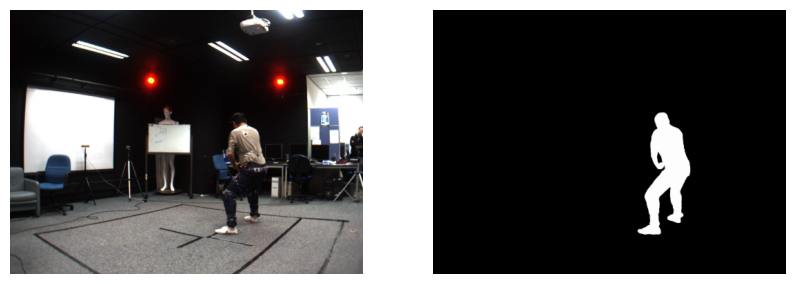

In [3]:
img, mask = load_image(fnames[5])

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img)
ax[1].imshow(mask)
ax[0].axis('off')
ax[1].axis('off')

## 打包数据集

为了真实的数据集，加了两条

In [69]:
import torchvision.transforms as transforms
transform_image = transforms.Compose([
    transforms.Resize((256,256)),
    # transforms.RandomHorizontalFlip(), # 随机翻转
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 随机改光照（这招对抵抗真实世界光照变化最有用！）
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_mask = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())

])

### 更优雅的处理方式
用 `torch.utils.data.Dataset`来创建一个新的数据集类

喔，注意mask一定要二值化，只有0和1

注意掩码不用正则化

In [70]:
import torch
import numpy as np
from PIL import  Image
torch.manual_seed(42)
np.random.seed(42)#设置随机数种子

class BodySegmentationDataset(torch.utils.data.Dataset):
    def __init__(self,dataset_path,transform_image=None,transform_mask=None):
        self.dataset_path = dataset_path
        self.transform_mask = transform_mask
        self.transform_image = transform_image
        self.images=sorted(os.listdir(os.path.join(dataset_path,'images')))

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):
        img_name = self.images[idx]
        img_path=os.path.join(self.dataset_path,'images',img_name)
        mask_path=os.path.join(self.dataset_path,'masks',img_name)
        image= Image.open(img_path).convert('RGB')
        mask= Image.open(mask_path).convert('L')
        if self.transform_image:
            image = self.transform_image(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)
        return image,mask
dataset=BodySegmentationDataset(dataset_path=dataset_path,transform_image=transform_image,transform_mask=transform_mask)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64,
                                           shuffle=True,num_workers=8,pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False,num_workers=8,pin_memory=True)


In [71]:
for images, masks in train_loader:
    print(images.shape)
    print(masks.shape)
    break

torch.Size([64, 3, 256, 256])
torch.Size([64, 1, 256, 256])


## 创建模型

In [72]:
import torch.nn as nn
class segnet(nn.Module):
    def __init__(self):
        super(segnet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=(2, 2)),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=(2, 2)),


            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=(2, 2)),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
        )

        self.decoder = nn.Sequential(
            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),

            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),

            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(32, 1, 3, padding=1),
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

这个网络好像太简单了，我用一个新的

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BetterSegNet(nn.Module): # 其实这就是一个简化版 U-Net
    def __init__(self):
        super(BetterSegNet, self).__init__()
        
        # Encoder (下采样)
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(16))
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(32))
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(64))
        self.pool3 = nn.MaxPool2d(2, 2)

        # Bottleneck (中间层)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(128),
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(64) # 输出改回64以便拼接
        )

        # Decoder (上采样)
        # 注意：输入通道数变大了，因为要拼接 encoder 的特征
        self.dec3 = nn.Sequential(nn.Conv2d(64 + 64, 32, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(32))
        self.dec2 = nn.Sequential(nn.Conv2d(32 + 32, 16, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(16))
        self.dec1 = nn.Sequential(nn.Conv2d(16 + 16, 1, 3, padding=1)) # 最后输出

    def forward(self, x):
        # 编码
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)
        
        # 中间
        b = self.bottleneck(p3)
        
        # 解码 + 跳跃连接 (Skip Connections)
        # 1. 上采样
        d3 = F.interpolate(b, scale_factor=2, mode='bilinear', align_corners=True)
        # 2. 拼接 (cat)
        d3 = torch.cat((d3, e3), dim=1) 
        d3 = self.dec3(d3)
        
        d2 = F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=True)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)
        
        d1 = F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=True)
        d1 = torch.cat((d1, e1), dim=1)
        out = self.dec1(d1)
        
        return out

In [33]:
device ="cuda" if torch.cuda.is_available() else "cpu"
model = segnet().to(device)
optimizer=torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-5)
loss_fn=nn.BCEWithLogitsLoss()

In [74]:
model2=BetterSegNet().to(device)
optimizer2=torch.optim.Adam(model2.parameters(), lr=0.001,weight_decay=1e-5)
device ="cuda" if torch.cuda.is_available() else "cpu"
loss_fn=nn.BCEWithLogitsLoss()

## 训练过程

In [63]:

save_dir = "body_model_save"
save_dir2="better_model_save"
os.makedirs(save_dir, exist_ok=True)
def train(model,train_loader,optimizer,loss_fn,device,save_dir,epochs=10):

    for epoch in range(epochs):
        train_loss=0
        model.train()
        for i,(images,masks) in enumerate(train_loader):
            images,masks=images.to(device),masks.to(device)

            optimizer.zero_grad()
            preds=model(images)
            loss=loss_fn(preds,masks)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

            if i%5==0:
                print(f"Epoch:{epoch}/{epochs} | Step:{i}/{len(train_loader)} | Loss:{loss.item()}")

        print(f"Epoch:{epoch}/{epochs} | Train Loss:{train_loss/len(train_loader)}")
        if epoch%10==0:
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": train_loss/len(train_loader),
            }, f"{save_dir}/checkpoint{epoch}.pth")


In [80]:
train(model2,train_loader,optimizer2,loss_fn,device,save_dir2,epochs=30)

Epoch:0/30 | Step:0/15 | Loss:0.014907232485711575
Epoch:0/30 | Step:5/15 | Loss:0.01443161629140377
Epoch:0/30 | Step:10/15 | Loss:0.014718664810061455
Epoch:0/30 | Train Loss:0.014912739458183447
Epoch:1/30 | Step:0/15 | Loss:0.014818363822996616
Epoch:1/30 | Step:5/15 | Loss:0.014385559596121311
Epoch:1/30 | Step:10/15 | Loss:0.014458974823355675
Epoch:1/30 | Train Loss:0.014342477420965831
Epoch:2/30 | Step:0/15 | Loss:0.014174094423651695
Epoch:2/30 | Step:5/15 | Loss:0.013797508552670479
Epoch:2/30 | Step:10/15 | Loss:0.01378381997346878
Epoch:2/30 | Train Loss:0.013450984656810761
Epoch:3/30 | Step:0/15 | Loss:0.012489955872297287
Epoch:3/30 | Step:5/15 | Loss:0.012926673516631126
Epoch:3/30 | Step:10/15 | Loss:0.013653193600475788
Epoch:3/30 | Train Loss:0.0127181863412261
Epoch:4/30 | Step:0/15 | Loss:0.012404114007949829
Epoch:4/30 | Step:5/15 | Loss:0.012073437683284283
Epoch:4/30 | Step:10/15 | Loss:0.011555776000022888
Epoch:4/30 | Train Loss:0.011983891079823176
Epoch:5/3

加载模型

In [12]:
checkpoint=torch.load("body_model_save/checkpoint30.pth")
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

## 评估模型效果
### 测试集损失

In [79]:
def evaluate(model,test_loader,device):
    model.eval()
    test_loss=0
    with torch.no_grad():
        for images,masks in test_loader:
            images,masks=images.to(device),masks.to(device)
            preds=model(images)
            loss=loss_fn(preds,masks)
            test_loss+=loss.item()
    print(f"Test Loss:{test_loss/len(test_loader)}")
evaluate(model2,test_loader,device)

Test Loss:0.017637941520661116


### 绘图

In [76]:
def show_body(image,pred):
    image_temp=image.clone()
    pred_picture=pred.copy()
    pred_picture=pred_picture[0]#去除第一个维度
    for i in range(3):
        image_temp[i][pred_picture==0]=0
    return image_temp

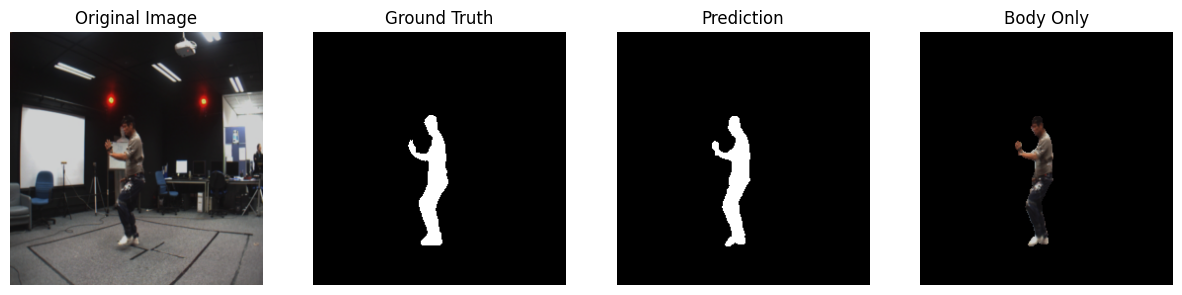

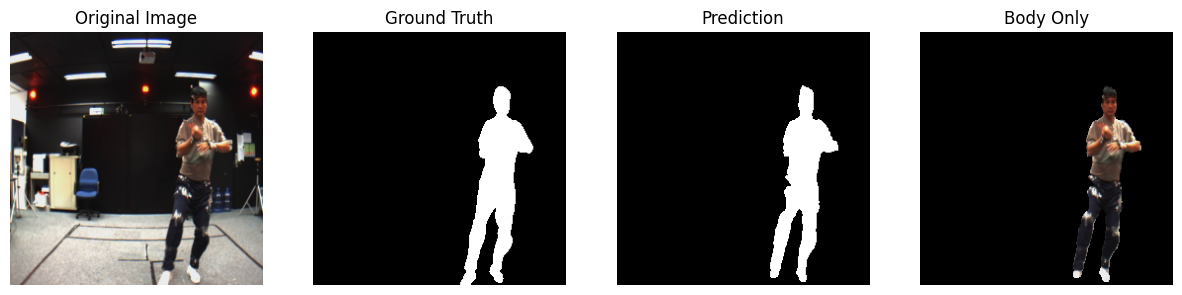

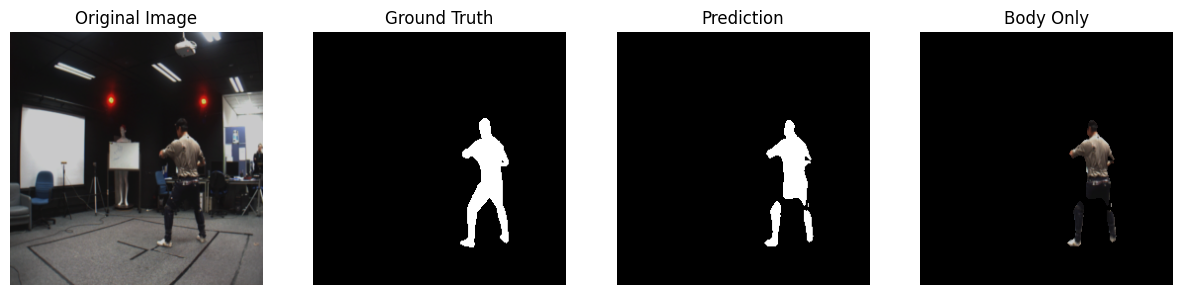

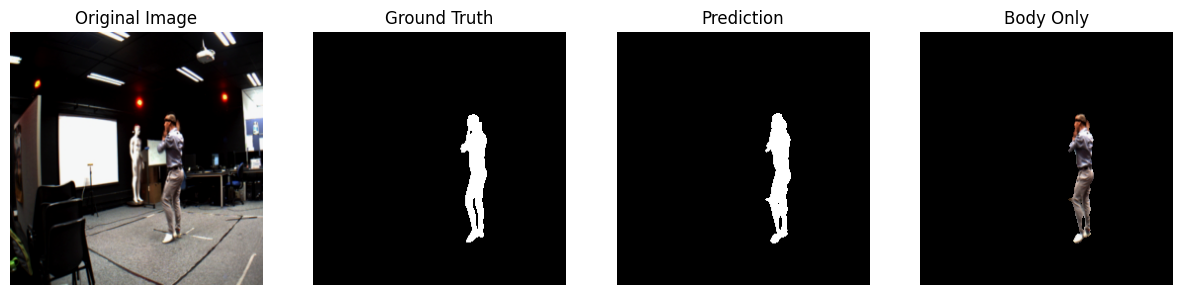

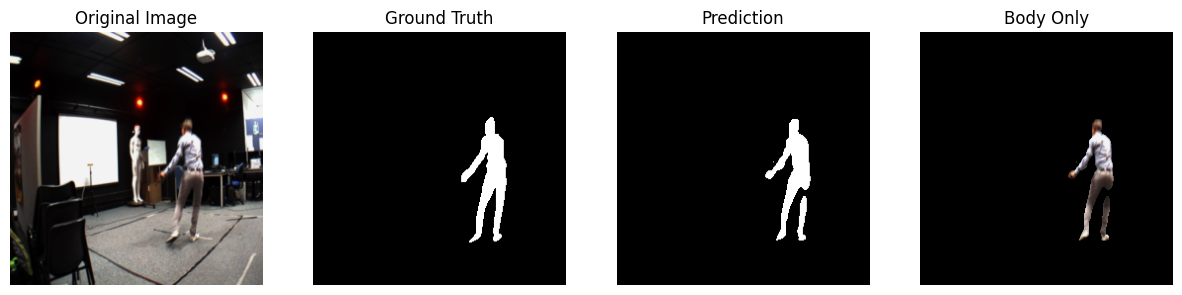

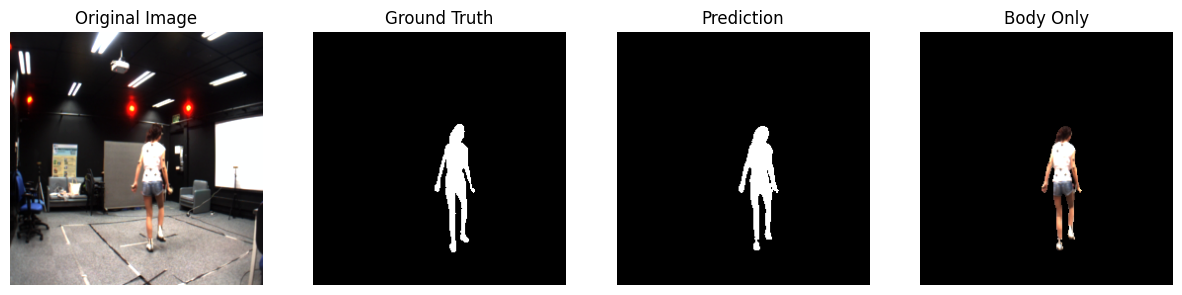

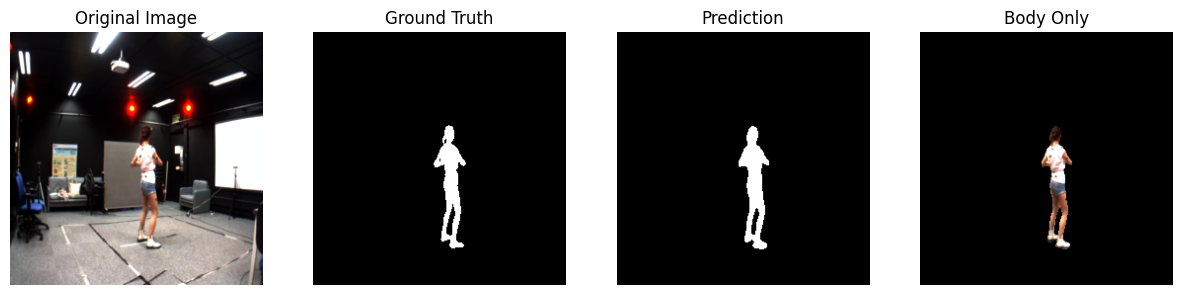

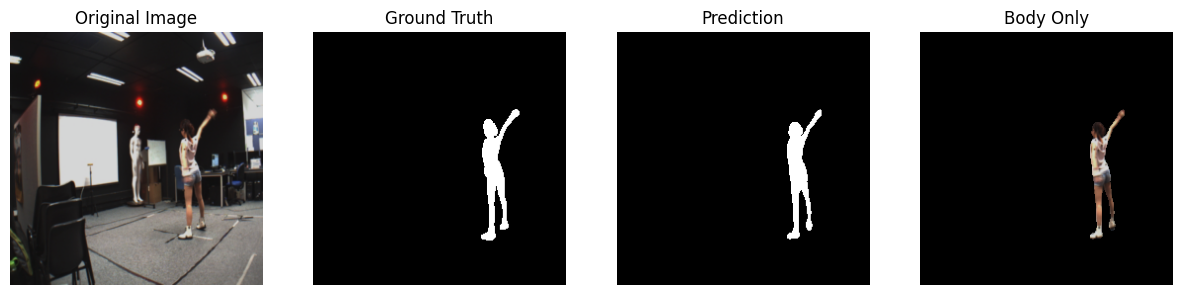

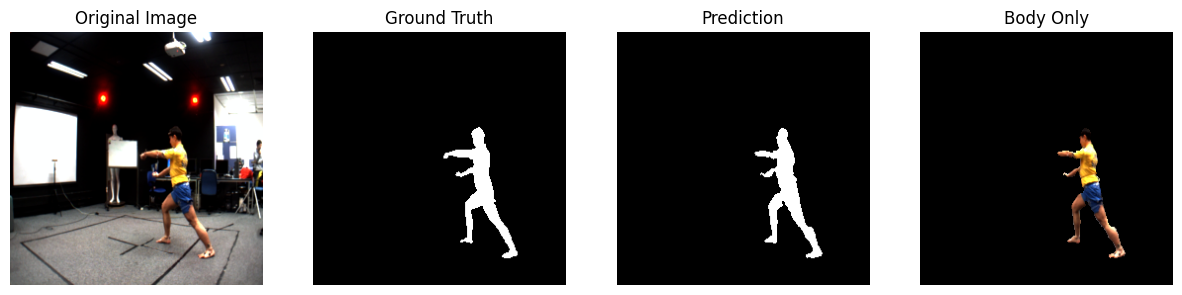

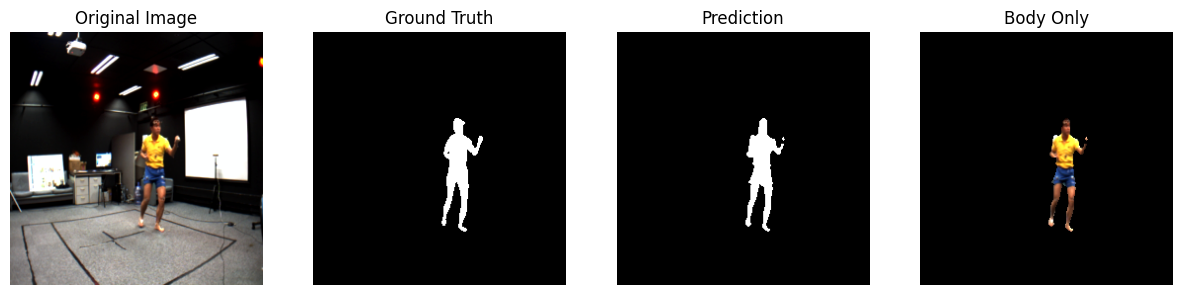

In [77]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def show_result(model, test_dataset, device, number=5):
    model.eval()
    # 随机选择图片
    indices = np.random.permutation(len(test_dataset))
    test_idx = indices[:number]

    for i in test_idx:
        image, mask = test_dataset[i]
        image, mask = image.to(device), mask.to(device)

        # 1. 模型预测
        with torch.no_grad(): # 加上 no_grad 节省显存
            preds = model(image.unsqueeze(0))
            # 处理预测结果：Sigmoid -> Squeeze -> 转CPU -> 转Numpy -> 二值化
            preds = torch.sigmoid(preds).squeeze().cpu().numpy()
            pred_mask = preds > 0.5 

        plt.figure(figsize=(15, 5))

        # --- 核心修改区域 ---
        
        # 2. 先把原图转为 Numpy 并反归一化 (H, W, C)
        img_np = image.cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1) # 限制在 0-1 之间

        # 3. 生成 Body Only 图片
        # 这里的逻辑是：由 Numpy 对 Numpy 操作，绝对不会报错
        # pred_mask 是 (H, W)，img_np 是 (H, W, 3)
        # 我们需要把 mask 扩展这一维才能相乘
        
        # 复制一份原图
        body_np = img_np.copy()
        
        # 方法 A：使用布尔索引将背景设为黑色 (推荐)
        # ~pred_mask 表示“非人”区域 (即背景)
        body_np[~pred_mask] = 0 
        
        # 方法 B (备选)：直接乘法 (pred_mask 需要扩展维度)
        # body_np = img_np * pred_mask[:, :, None]

        # --- 绘图区域 ---

        plt.subplot(1, 4, 1)
        plt.imshow(img_np)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 4, 2)
        plt.imshow(mask.cpu().numpy().squeeze(), cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(pred_mask, cmap='gray') # 显示二值化后的预测
        plt.title('Prediction')
        plt.axis('off')

        plt.subplot(1, 4, 4)
        plt.imshow(body_np)
        plt.title('Body Only')
        plt.axis("off")

        plt.show()
        # plt.pause(0.5) # 在某些环境下 pause 会导致闪退，如果不需要自动播放建议注释掉
        # plt.close()    # 如果是在 Jupyter Notebook 里，建议注释掉 close，否则图会消失

# 调用函数
show_result(model2, test_dataset, device,10)

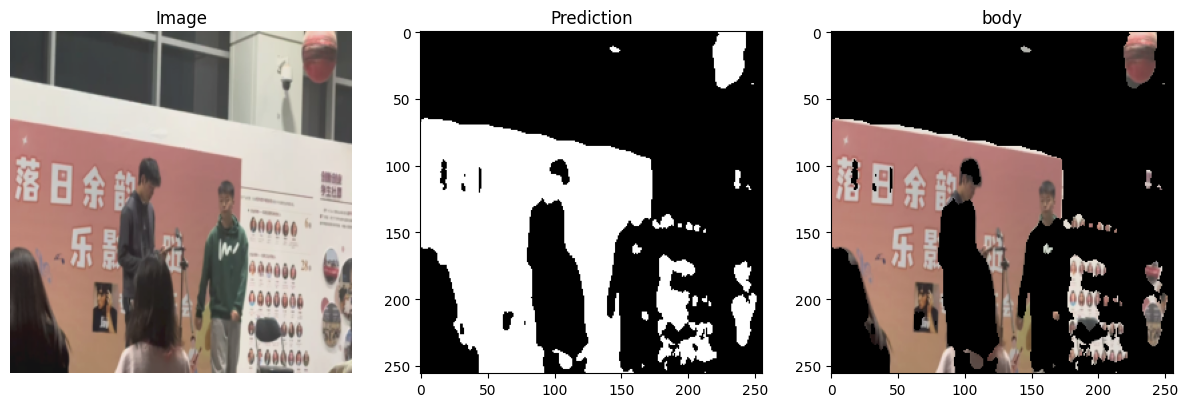

In [78]:
from PIL import Image
img_path="person1.jpg"
image=Image.open(img_path).convert("RGB")
image=transform_image(image).to(device)
predict_image=model2(image.unsqueeze(0))
preds=torch.sigmoid(predict_image.detach()).squeeze().cpu().numpy()
preds=preds>0.5#转为预测掩码，只有0和1
plt.figure(figsize=(15,5))


img_np = image.cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
# ！！！关键步骤：反归    一化 ！！！
img_np = img_np * std + mean

# ！！！重要：确保像素值在 [0, 1] 范围内 ！！！
# 由于数值计算的微小误差，可能会有略微超出范围的值，需要裁剪
img_np = np.clip(img_np, 0, 1)

body_only=img_np.copy()

body_only[~preds]=0

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title('Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(preds,cmap='gray')
plt.title('Prediction')

plt.subplot(1,3,3)
plt.imshow(body_only)
plt.title('body')

plt.show()
plt.pause(0.5)
plt.close()

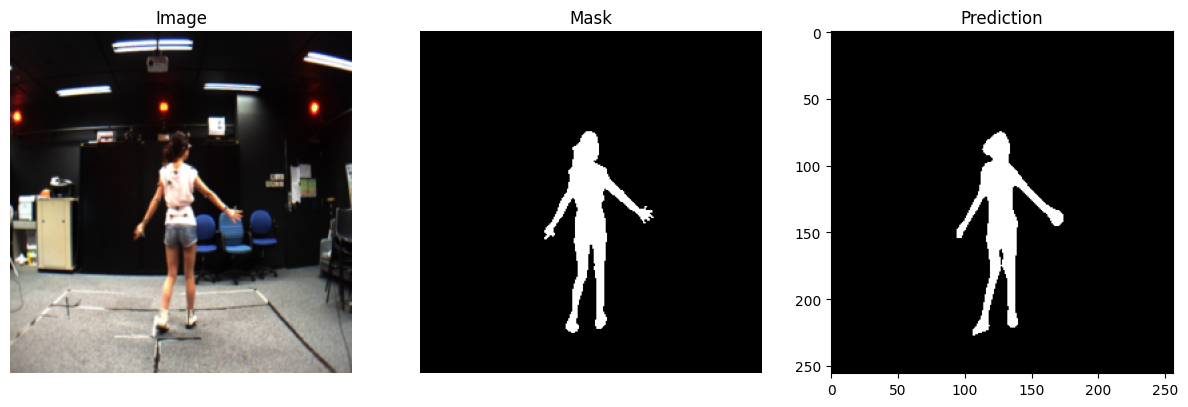

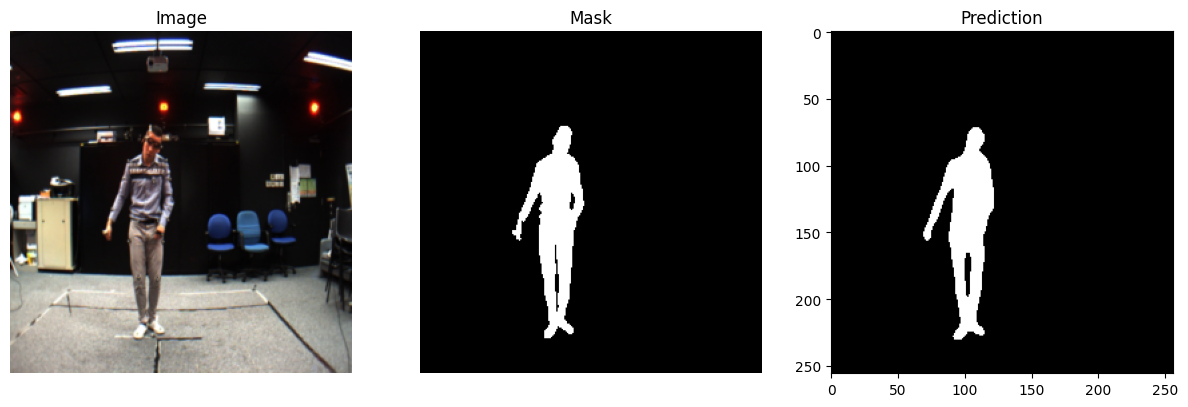

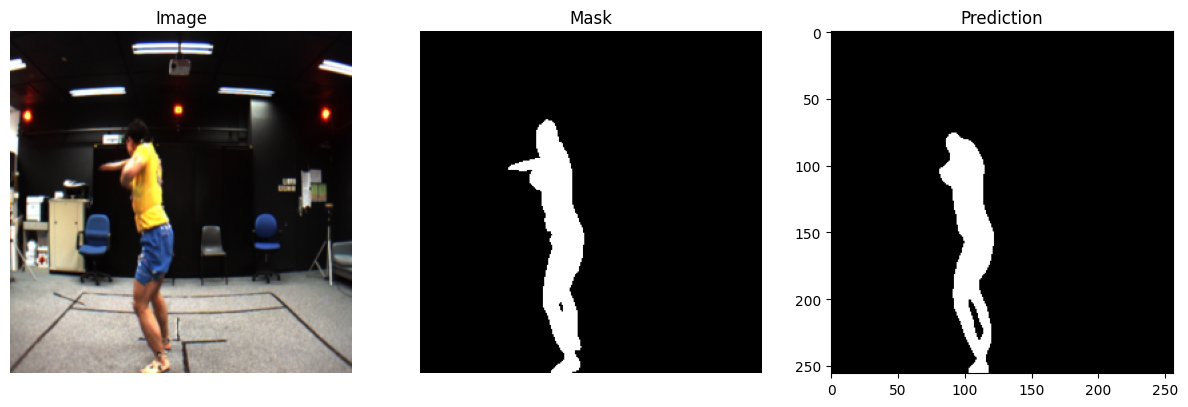

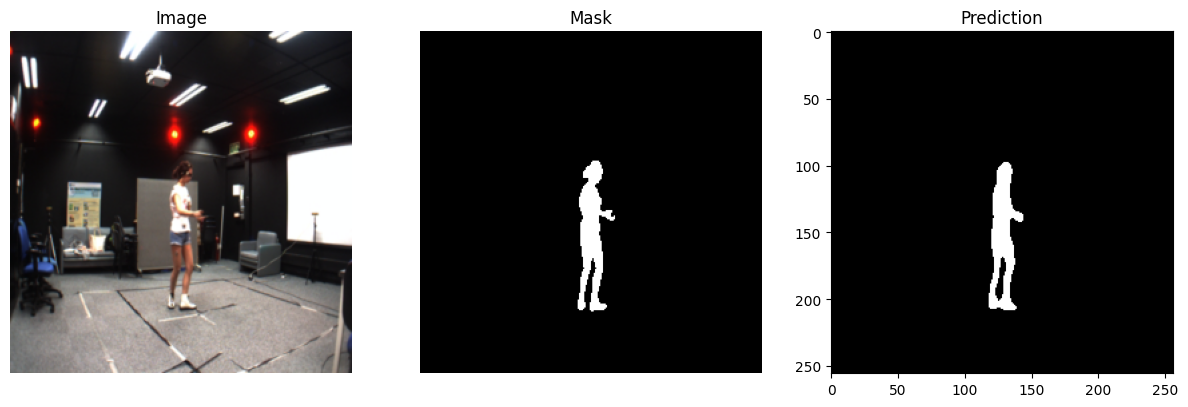

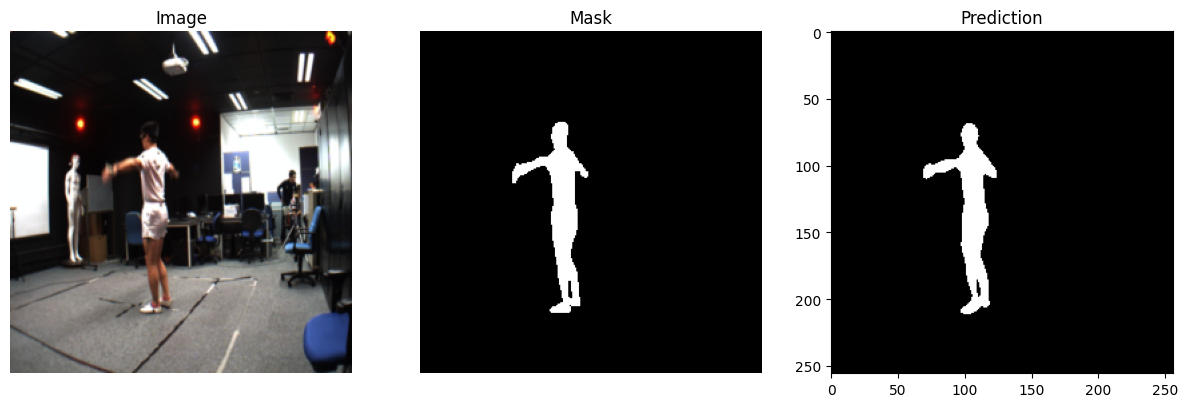

In [34]:

show_result(model,test_dataset,device)


---

**免责声明**：  
本文档使用AI翻译服务[Co-op Translator](https://github.com/Azure/co-op-translator)进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的文档应被视为权威来源。对于关键信息，建议使用专业人工翻译。我们对因使用此翻译而产生的任何误解或误读不承担责任。
